# 40 — FNSPID transfer of the LSEG/Gemma continuous strategy base

**Question.** Does Notebook 39's return-free, calibration-portable LSEG/Gemma
rule have economic value in the separate 2011–2023 FNSPID regime?

**Frozen translation before returns.** Notebook 39 fixes mean continuous
firm-open sentiment, a cross-sectional q90−q10 dispersion trigger at the
strictly prior trailing-60 75th percentile after 40 observations, top and
bottom 2/33 of the cross-section, a 25% name cap, dollar neutrality, one
open-to-open interval, and 10 bps per traded side. Only 9/33 LSEG symbols
exist in the FNSPID checkpoint, so exact-name replay is infeasible. This
notebook preserves the relative breadth (2/33) across all FNSPID news-bearing
firms, with a minimum two names per leg. No parameter is selected on FNSPID
returns.

**Outcome status.** FNSPID development is through 2019-12-31 and evaluation
begins 2020-01-01. These outcomes were opened elsewhere in the research
programme, so this is an externally specified, post-research cross-regime
replay—not pristine confirmation.

**Predeclared gates.** Feasibility requires at least 60 active sessions in
each split and in both evaluation halves. The cash gate requires positive
evaluation net Sharpe, break-even above 10 bps, a positive 95% block interval
versus cash with p<0.05, and non-negative Sharpe in development and both
evaluation halves. Timing and name-selection randomisation p-values form one
two-test BH family. A separate HAC(5) SPY-plus-universe alpha gate is reported.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sparse_spread import ledger_rows_to_frame  # noqa: E402
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)
from sentiment_benchmark.trading_effectiveness import (  # noqa: E402
    benjamini_hochberg,
)

SEED = 20260814
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATIONS = 9_999
RANDOM_REPLICATIONS = 999
TRAILING_SESSIONS = 60
MIN_TRAILING_SESSIONS = 40
EVENT_INTENSITY_QUANTILE = 0.75
RELATIVE_BREADTH = 2.0 / 33.0
MINIMUM_NAMES_PER_LEG = 2
SINGLE_NAME_CAP = 0.25
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0

AGGREGATE_PATH = (
    REPO_ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet"
)
PANEL_PATH = REPO_ROOT / "final_experiments/outputs/01_panel/fnspid_firm_day_panel.parquet"
NOTEBOOK39_MANIFEST = (
    REPO_ROOT / "final_experiments/outputs/39_gemma_continuous_portability/manifest.json"
)
OUTPUT_DIR = (
    REPO_ROOT
    / "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Bind the frozen LSEG/Gemma specification

This stage reads only signal and calendar columns from FNSPID. Return columns
remain unopened until the specification and feasibility audit below are
materialised.

In [2]:
notebook39_manifest = json.loads(NOTEBOOK39_MANIFEST.read_text())
expected_spec = {
    "firm_open_reducer": "mean_continuous",
    "long_names": 2,
    "short_names": 2,
    "single_name_cap": 0.25,
    "gross_exposure": 1.0,
    "holding_intervals": 1,
    "cost_bps_per_side_for_future_test": 10.0,
    "current_return_window_evaluated": False,
}
selected_spec = notebook39_manifest["selected_future_specification"]
for key, expected in expected_spec.items():
    if selected_spec.get(key) != expected:
        raise ValueError(f"Notebook 39 specification mismatch for {key}")
adaptive_spec = notebook39_manifest["adaptive_schedule"]
if adaptive_spec != {
    "top_bottom_names": 2,
    "trailing_sessions": 60,
    "minimum_trailing_sessions": 40,
    "event_intensity_quantile": 0.75,
}:
    raise ValueError("Notebook 39 adaptive schedule changed")

signal = pd.read_parquet(
    AGGREGATE_PATH,
    columns=["symbol", "session_date", "split", "mean_continuous"],
)
signal["session_date"] = pd.to_datetime(signal["session_date"]).dt.normalize()
signal = signal.sort_values(["session_date", "symbol"], kind="mergesort").reset_index(
    drop=True
)
if signal.duplicated(["session_date", "symbol"]).any():
    raise ValueError("FNSPID signal panel is not unique by firm-session")
if signal["mean_continuous"].isna().any():
    raise ValueError("FNSPID mean-continuous signal contains missing values")

daily_input = (
    signal.groupby(["session_date", "split"], sort=True)
    .agg(
        available_names=("symbol", "nunique"),
        q10=("mean_continuous", lambda values: float(values.quantile(0.10))),
        q90=("mean_continuous", lambda values: float(values.quantile(0.90))),
    )
    .reset_index()
    .sort_values("session_date", kind="mergesort")
    .reset_index(drop=True)
)
daily_input["dispersion"] = daily_input["q90"] - daily_input["q10"]
daily_input["trailing_threshold"] = (
    daily_input["dispersion"]
    .shift(1)
    .rolling(TRAILING_SESSIONS, min_periods=MIN_TRAILING_SESSIONS)
    .quantile(EVENT_INTENSITY_QUANTILE)
)
daily_input["active"] = daily_input["trailing_threshold"].notna() & daily_input[
    "dispersion"
].ge(daily_input["trailing_threshold"])
daily_input["names_per_leg"] = np.maximum(
    MINIMUM_NAMES_PER_LEG,
    np.ceil(daily_input["available_names"] * RELATIVE_BREADTH),
).astype(int)
if (2 * daily_input["names_per_leg"] > daily_input["available_names"]).any():
    raise RuntimeError("translated breadth creates overlapping legs")

eval_dates = daily_input.loc[
    daily_input["split"].eq("evaluation"), "session_date"
].sort_values()
evaluation_midpoint = pd.Timestamp(eval_dates.iloc[len(eval_dates) // 2])
feasibility = pd.DataFrame(
    [
        {
            "sessions": len(daily_input),
            "development_sessions": int(daily_input["split"].eq("development").sum()),
            "evaluation_sessions": int(daily_input["split"].eq("evaluation").sum()),
            "development_active": int(
                daily_input.eval("split == 'development' and active").sum()
            ),
            "evaluation_active": int(
                daily_input.eval("split == 'evaluation' and active").sum()
            ),
            "evaluation_first_half_active": int(
                (
                    daily_input["split"].eq("evaluation")
                    & daily_input["session_date"].lt(evaluation_midpoint)
                    & daily_input["active"]
                ).sum()
            ),
            "evaluation_second_half_active": int(
                (
                    daily_input["split"].eq("evaluation")
                    & daily_input["session_date"].ge(evaluation_midpoint)
                    & daily_input["active"]
                ).sum()
            ),
            "minimum_available_names": int(daily_input["available_names"].min()),
            "median_available_names": float(daily_input["available_names"].median()),
            "median_names_per_leg": float(daily_input["names_per_leg"].median()),
            "evaluation_midpoint": evaluation_midpoint,
        }
    ]
)
feasibility_gate = bool(
    feasibility.loc[0, "development_active"] >= MINIMUM_ACTIVE_SESSIONS
    and feasibility.loc[0, "evaluation_active"] >= MINIMUM_ACTIVE_SESSIONS
    and feasibility.loc[0, "evaluation_first_half_active"]
    >= MINIMUM_ACTIVE_SESSIONS
    and feasibility.loc[0, "evaluation_second_half_active"]
    >= MINIMUM_ACTIVE_SESSIONS
)
if not feasibility_gate:
    raise RuntimeError("return-free FNSPID feasibility gate failed")
display(feasibility.T)

,0
sessions,3262
development_sessions,2264
evaluation_sessions,998
development_active,570
evaluation_active,261
evaluation_first_half_active,135
evaluation_second_half_active,126
minimum_available_names,67
median_available_names,216.000000
median_names_per_leg,14.000000


## Frozen target matrices

Positive mean sentiment is long and negative relative sentiment is short.
Every active book is gross one and dollar neutral. The final development
decision session is forced to cash when its return endpoint crosses into the
evaluation block; evaluation starts from cash.

In [3]:
sessions = pd.DatetimeIndex(sorted(signal["session_date"].unique()))
symbols = tuple(sorted(signal["symbol"].unique()))
session_index = {session: index for index, session in enumerate(sessions)}
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
rank_weights = np.zeros((len(sessions), len(symbols)), dtype=float)
availability = np.zeros_like(rank_weights, dtype=bool)
breadth_by_session = np.zeros(len(sessions), dtype=int)

input_lookup = daily_input.set_index("session_date")
for session, day in signal.groupby("session_date", sort=True):
    row_index = session_index[pd.Timestamp(session)]
    ordered = day.sort_values(
        ["mean_continuous", "symbol"], ascending=[True, True], kind="mergesort"
    )
    available_indices = np.array(
        [symbol_index[symbol] for symbol in ordered["symbol"]], dtype=int
    )
    availability[row_index, available_indices] = True
    names_per_leg = int(input_lookup.loc[session, "names_per_leg"])
    breadth_by_session[row_index] = names_per_leg
    short_indices = available_indices[:names_per_leg]
    long_indices = available_indices[-names_per_leg:]
    rank_weights[row_index, long_indices] = 0.5 / names_per_leg
    rank_weights[row_index, short_indices] = -0.5 / names_per_leg

active_flag = input_lookup.reindex(sessions)["active"].to_numpy(dtype=bool)
gated_weights = rank_weights * active_flag[:, None]
split_by_session = input_lookup.reindex(sessions)["split"].astype(str).to_numpy()
development_indices = np.flatnonzero(split_by_session == "development")
evaluation_indices = np.flatnonzero(split_by_session == "evaluation")
if not np.array_equal(
    np.r_[development_indices, evaluation_indices], np.arange(len(sessions))
):
    raise ValueError("FNSPID split sessions are not chronological contiguous blocks")

## Open the FNSPID outcome columns once

In [4]:
outcomes = pd.read_parquet(
    AGGREGATE_PATH,
    columns=[
        "symbol",
        "session_date",
        "ret_open_h1",
        "spy_ret_open_h1",
    ],
)
outcomes["session_date"] = pd.to_datetime(outcomes["session_date"]).dt.normalize()
panel_clock = pd.read_parquet(
    PANEL_PATH,
    columns=["symbol", "session_date", "return_end_date"],
)
panel_clock["session_date"] = pd.to_datetime(panel_clock["session_date"]).dt.normalize()
panel_clock["return_end_date"] = pd.to_datetime(
    panel_clock["return_end_date"]
).dt.normalize()
clock = (
    panel_clock[["session_date", "return_end_date"]]
    .dropna(subset=["return_end_date"])
    .drop_duplicates()
)
if clock.groupby("session_date")["return_end_date"].nunique().max() != 1:
    raise ValueError("FNSPID firms disagree on the immediate return endpoint")
clock = clock.drop_duplicates("session_date").set_index("session_date").reindex(sessions)
if clock["return_end_date"].isna().any():
    raise ValueError("FNSPID session clock is incomplete")
next_sessions = pd.DatetimeIndex(clock["return_end_date"])
if not np.array_equal(next_sessions[:-1], sessions[1:]):
    raise ValueError("FNSPID decision sessions are not consecutive exchange sessions")

outcome_panel = signal[["session_date", "symbol"]].merge(
    outcomes,
    on=["session_date", "symbol"],
    how="left",
    validate="one_to_one",
)
return_matrix = np.full_like(rank_weights, np.nan, dtype=float)
for row in outcome_panel.itertuples(index=False):
    return_matrix[
        session_index[pd.Timestamp(row.session_date)], symbol_index[str(row.symbol)]
    ] = float(row.ret_open_h1)
prepolicy_selected_mask = ~np.isclose(rank_weights, 0.0)
missing_selected_mask = prepolicy_selected_mask & ~np.isfinite(return_matrix)
incomplete_session_indices = np.unique(np.argwhere(missing_selected_mask)[:, 0])
outcome_availability_audit = pd.DataFrame(
    [
        {
            "missing_returns_in_news_panel": int(
                outcome_panel["ret_open_h1"].isna().sum()
            ),
            "missing_frozen_selected_positions": int(missing_selected_mask.sum()),
            "affected_sessions": len(incomplete_session_indices),
            "affected_session_dates": "|".join(
                str(sessions[index].date()) for index in incomplete_session_indices
            ),
            "policy": "fail closed to cash for the complete affected session",
        }
    ]
)
# A missing immediate stock return is not replaced, skipped, or treated as zero.
# The complete session is forced to cash for both the adaptive rule and its
# always-active comparator. This policy depends only on outcome availability,
# never on the realised return sign or magnitude.
rank_weights[incomplete_session_indices] = 0.0
gated_weights[incomplete_session_indices] = 0.0
active_flag[incomplete_session_indices] = False
selected_mask = ~np.isclose(rank_weights, 0.0)
if not np.isfinite(return_matrix[selected_mask]).all():
    raise RuntimeError("fail-closed missing-return policy is incomplete")
safe_returns = np.where(np.isfinite(return_matrix), return_matrix, 0.0)

factor_panel = (
    outcome_panel.groupby("session_date", sort=True)
    .agg(
        equal_weight_news_market=("ret_open_h1", "mean"),
        spy_return=("spy_ret_open_h1", "first"),
    )
    .reindex(sessions)
)
factor_panel.index.name = "session_date"
factor_panel = factor_panel.reset_index()
if factor_panel[["equal_weight_news_market", "spy_return"]].isna().any().any():
    raise RuntimeError("factor panel is incomplete")

# Force cash on the single development session whose return endpoint is in evaluation.
boundary_crossing = (split_by_session == "development") & (
    next_sessions.year.to_numpy() >= 2020
)
if int(boundary_crossing.sum()) != 1:
    raise RuntimeError("expected exactly one development/evaluation boundary interval")
rank_weights[boundary_crossing] = 0.0
gated_weights[boundary_crossing] = 0.0
active_flag[boundary_crossing] = False
display(outcome_availability_audit.T)


def matrix_backtest(
    weights: np.ndarray,
    returns: np.ndarray,
    decision_sessions: pd.DatetimeIndex,
    return_end_sessions: pd.DatetimeIndex,
    *,
    cost_bps: float,
) -> pd.DataFrame:
    if weights.shape != returns.shape or weights.shape[0] != len(decision_sessions):
        raise ValueError("matrix backtest inputs do not align")
    current = np.zeros(weights.shape[1], dtype=float)
    gross_rows = []
    net_rows = []
    turnover_rows = []
    cost_rows = []
    gross_exposure_rows = []
    active_name_rows = []
    rate = cost_bps / 10_000.0
    for target, asset_returns in zip(weights, returns, strict=True):
        if not np.isfinite(asset_returns[~np.isclose(target, 0.0)]).all():
            raise RuntimeError("active target has a missing return")
        asset_returns = np.where(np.isfinite(asset_returns), asset_returns, 0.0)
        turnover = float(np.abs(target - current).sum())
        cost = rate * turnover
        gross = float(np.dot(target, asset_returns))
        net = gross - cost
        if 1.0 + net <= 0:
            raise RuntimeError("strategy NAV became non-positive")
        current = target * (1.0 + asset_returns) / (1.0 + net)
        gross_rows.append(gross)
        net_rows.append(net)
        turnover_rows.append(turnover)
        cost_rows.append(cost)
        gross_exposure_rows.append(float(np.abs(target).sum()))
        active_name_rows.append(int(np.count_nonzero(target)))
    liquidation_turnover = float(np.abs(current).sum())
    liquidation_cost = rate * liquidation_turnover
    net_rows[-1] = (1.0 + net_rows[-1]) * (1.0 - liquidation_cost) - 1.0
    turnover_rows[-1] += liquidation_turnover
    cost_rows[-1] += liquidation_cost
    return pd.DataFrame(
        {
            "session_date": decision_sessions,
            "next_session": return_end_sessions,
            "gross_return": gross_rows,
            "net_return": net_rows,
            "turnover": turnover_rows,
            "cost": cost_rows,
            "gross_exposure": gross_exposure_rows,
            "active_names": active_name_rows,
        }
    )


def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"])
        - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    return intervals


def matrix_to_targets(
    weights: np.ndarray, decision_sessions: pd.DatetimeIndex
) -> tuple[TargetPortfolio, ...]:
    targets = []
    for session, vector in zip(decision_sessions, weights, strict=True):
        nonzero = np.flatnonzero(~np.isclose(vector, 0.0))
        positions = tuple(
            PositionTarget(
                symbol=symbols[index],
                action=float(np.sign(vector[index])),
                volatility=None,
                raw_weight=float(vector[index]),
                target_weight=float(vector[index]),
                exclusion_reason=None,
            )
            for index in nonzero
        )
        long_exposure = float(vector[vector > 0].sum())
        short_exposure = float(-vector[vector < 0].sum())
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(session).date()),
                positions=positions,
                gross_exposure=long_exposure + short_exposure,
                net_exposure=long_exposure - short_exposure,
                long_exposure=long_exposure,
                short_exposure=short_exposure,
                cash_weight=1.0 - (long_exposure - short_exposure),
            )
        )
    return tuple(targets)


def matrix_to_return_rows(
    weights: np.ndarray,
    returns: np.ndarray,
    decision_sessions: pd.DatetimeIndex,
    return_end_sessions: pd.DatetimeIndex,
) -> list[OpenToOpenReturn]:
    rows = []
    for session, next_session, vector, asset_returns in zip(
        decision_sessions, return_end_sessions, weights, returns, strict=True
    ):
        rows.append(
            OpenToOpenReturn(
                symbol="__CLOCK__",
                session=str(pd.Timestamp(session).date()),
                next_session=str(pd.Timestamp(next_session).date()),
                value=0.0,
            )
        )
        for index in np.flatnonzero(~np.isclose(vector, 0.0)):
            rows.append(
                OpenToOpenReturn(
                    symbol=symbols[index],
                    session=str(pd.Timestamp(session).date()),
                    next_session=str(pd.Timestamp(next_session).date()),
                    value=float(asset_returns[index]),
                )
            )
    return rows


def validate_against_ledger(
    weights: np.ndarray,
    returns: np.ndarray,
    decision_sessions: pd.DatetimeIndex,
    return_end_sessions: pd.DatetimeIndex,
    matrix_daily: pd.DataFrame,
) -> dict[str, float]:
    ledger = ledger_rows_to_frame(
        run_open_to_open_ledger(
            matrix_to_targets(weights, decision_sessions),
            matrix_to_return_rows(
                weights, returns, decision_sessions, return_end_sessions
            ),
            cost_rate_per_side=COST_BPS / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    ledger = fold_final_liquidation(ledger)
    errors = {
        column: float((ledger[column] - matrix_daily[column]).abs().max())
        for column in ("gross_return", "net_return", "turnover")
    }
    if max(errors.values()) > 1e-12:
        raise RuntimeError(f"matrix accounting does not match ledger: {errors}")
    return errors


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * np.sqrt(252)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover)
        if turnover > 0
        else float("nan"),
        "cost_bps_per_side": cost_bps,
    }


split_matrices = {
    "development": development_indices,
    "evaluation": evaluation_indices,
}
daily_paths = {}
strategy_rows = []
accounting_audit_rows = []
for split_name, indices in split_matrices.items():
    split_sessions = sessions[indices]
    split_next = next_sessions[indices]
    split_returns = safe_returns[indices]
    for strategy_name, weights in (
        ("adaptive_dispersion", gated_weights[indices]),
        ("always_active_rank", rank_weights[indices]),
    ):
        daily = matrix_backtest(
            weights,
            split_returns,
            split_sessions,
            split_next,
            cost_bps=COST_BPS,
        )
        daily_paths[(split_name, strategy_name)] = daily
        strategy_rows.append(
            {
                "split": split_name,
                "strategy": strategy_name,
                **summarize(daily, cost_bps=COST_BPS),
            }
        )
        errors = validate_against_ledger(
            weights, split_returns, split_sessions, split_next, daily
        )
        accounting_audit_rows.append(
            {"split": split_name, "strategy": strategy_name, **errors}
        )
strategy_results = pd.DataFrame(strategy_rows)
accounting_audit = pd.DataFrame(accounting_audit_rows)
display(strategy_results)
display(accounting_audit)

,0
missing_returns_in_news_panel,12
missing_frozen_selected_positions,1
affected_sessions,1
affected_session_dates,2020-04-01
policy,fail closed to cash for the complete affected ...


,split,strategy,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,development,adaptive_dispersion,2264,569,0.000026,-0.000467,0.186931,-3.214812,0.036597,0.055280,-0.654674,-0.657889,0.493118,"1,116.419091",0.532248,10.000000
1,development,always_active_rank,2264,2263,0.000119,-0.001788,0.443162,-6.686772,0.067395,0.281571,-0.982971,-0.983101,1.906929,"4,317.286668",0.622017,10.000000
2,evaluation,adaptive_dispersion,998,260,0.000249,-0.000258,1.056162,-1.103251,0.059044,0.272884,-0.232719,-0.297056,0.507250,506.235007,4.904039,10.000000
3,evaluation,always_active_rank,998,997,0.000575,-0.001332,1.037353,-2.401818,0.139725,0.711403,-0.744993,-0.788309,1.906714,"1,902.900433",3.015601,10.000000


,split,strategy,gross_return,net_return,turnover
0,development,adaptive_dispersion,0.000000,0.000000,0.000000
1,development,always_active_rank,0.000000,0.000000,0.000000
2,evaluation,adaptive_dispersion,0.000000,0.000000,0.000000
3,evaluation,always_active_rank,0.000000,0.000000,0.000000


## Costs, cash/comparator inference, and stability

In [5]:
cost_rows = []
for split_name, indices in split_matrices.items():
    for cost_bps in COST_GRID:
        daily = matrix_backtest(
            gated_weights[indices],
            safe_returns[indices],
            sessions[indices],
            next_sessions[indices],
            cost_bps=cost_bps,
        )
        cost_rows.append(
            {
                "split": split_name,
                **summarize(daily, cost_bps=cost_bps),
            }
        )
cost_curve = pd.DataFrame(cost_rows)

inference_rows = []
for split_index, split_name in enumerate(("development", "evaluation")):
    gated_daily = daily_paths[(split_name, "adaptive_dispersion")]
    always_daily = daily_paths[(split_name, "always_active_rank")]
    cash = gated_daily[["session_date"]].copy()
    cash["net_return"] = 0.0
    cash_result = paired_block_bootstrap_difference(
        gated_daily,
        cash,
        value_col="net_return",
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 10 * split_index,
    )
    comparator_result = paired_block_bootstrap_difference(
        gated_daily,
        always_daily,
        value_col="net_return",
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 10 * split_index + 1,
    )
    inference_rows.extend(
        [
            {"split": split_name, "comparison": "adaptive_minus_cash", **cash_result},
            {
                "split": split_name,
                "comparison": "adaptive_minus_always_active",
                **comparator_result,
            },
        ]
    )
inference = pd.DataFrame(inference_rows)

evaluation_daily = daily_paths[("evaluation", "adaptive_dispersion")]
evaluation_half_rows = []
for half_name, mask in (
    ("first_half", evaluation_daily["session_date"].lt(evaluation_midpoint)),
    ("second_half", evaluation_daily["session_date"].ge(evaluation_midpoint)),
):
    evaluation_half_rows.append(
        {
            "period": half_name,
            **summarize(
                evaluation_daily.loc[mask].reset_index(drop=True), cost_bps=COST_BPS
            ),
        }
    )
evaluation_halves = pd.DataFrame(evaluation_half_rows)

year_rows = []
for year, year_daily in evaluation_daily.groupby(
    evaluation_daily["session_date"].dt.year, sort=True
):
    year_rows.append(
        {
            "year": int(year),
            **summarize(year_daily.reset_index(drop=True), cost_bps=COST_BPS),
        }
    )
year_results = pd.DataFrame(year_rows)
display(cost_curve)
display(inference)
display(evaluation_halves)
display(year_results)

,split,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,development,2264,569,0.000026,0.000026,0.186931,0.186931,0.035382,0.055280,0.055280,-0.094654,0.492793,"1,115.682406",0.532599,0.000000
1,development,2264,569,0.000026,-0.000023,0.186931,-0.164097,0.035377,0.055280,-0.056132,-0.112509,0.492825,"1,115.755947",0.532564,1.000000
2,development,2264,569,0.000026,-0.000072,0.186931,-0.514865,0.035400,0.055280,-0.155807,-0.172543,0.492858,"1,115.829514",0.532529,2.000000
3,development,2264,569,0.000026,-0.000220,0.186931,-1.557191,0.035640,0.055280,-0.396110,-0.404965,0.492955,"1,116.050374",0.532424,5.000000
4,development,2264,569,0.000026,-0.000467,0.186931,-3.214812,0.036597,0.055280,-0.654674,-0.657889,0.493118,"1,116.419091",0.532248,10.000000
5,evaluation,998,260,0.000249,0.000249,1.056162,1.056162,0.059353,0.272884,0.272884,-0.129160,0.506898,505.883932,4.907442,0.000000
6,evaluation,998,260,0.000249,0.000198,1.056162,0.842567,0.059238,0.272884,0.210132,-0.140733,0.506933,505.918965,4.907103,1.000000
7,evaluation,998,260,0.000249,0.000147,1.056162,0.627912,0.059141,0.272884,0.150457,-0.152156,0.506968,505.954012,4.906763,2.000000
8,evaluation,998,260,0.000249,-0.000005,1.056162,-0.020427,0.058963,0.272884,-0.011566,-0.187468,0.507073,506.059259,4.905742,5.000000
9,evaluation,998,260,0.000249,-0.000258,1.056162,-1.103251,0.059044,0.272884,-0.232719,-0.297056,0.507250,506.235007,4.904039,10.000000


,split,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,development,adaptive_minus_cash,2264,-0.000467,-0.000569,-0.000364,0.000100,5,9999,20260814
1,development,adaptive_minus_always_active,2264,0.001321,0.001174,0.001473,0.000100,5,9999,20260815
2,evaluation,adaptive_minus_cash,998,-0.000258,-0.000466,-0.000041,0.018500,5,9999,20260824
3,evaluation,adaptive_minus_always_active,998,0.001073,0.000592,0.001495,0.000200,5,9999,20260825


,period,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,first_half,499,134,0.000154,-0.000374,0.527451,-1.282884,0.073411,0.073943,-0.174569,-0.251998,0.527328,263.136805,2.912891,10.000000
1,second_half,499,126,0.000344,-0.000143,2.125583,-0.907267,0.039792,0.185244,-0.070448,-0.082180,0.487171,243.098203,7.059318,10.000000


,year,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,2020,253,67,0.000502,-0.000013,1.457833,-0.037895,0.085573,0.131167,-0.006890,-0.090163,0.514970,130.287294,9.750120,10.000000
1,2021,252,67,-0.000200,-0.000727,-0.910746,-3.200912,0.057244,-0.050589,-0.168843,-0.189715,0.527181,132.849510,-3.792471,10.000000
2,2022,251,71,0.000378,-0.000164,2.481620,-1.104599,0.037501,0.098729,-0.041092,-0.059081,0.542473,136.160764,6.969833,10.000000
3,2023,242,55,0.000317,-0.000125,1.830259,-0.739320,0.042576,0.078740,-0.030614,-0.067695,0.441890,106.937438,7.173257,10.000000


## Exact timing shifts and conditional random-name null

Timing shifts preserve the complete evaluation active/inactive sequence and
daily rank/count construction while breaking alignment between dispersion
intensity and returns. The conditional name null keeps the observed active
dates and leg counts but randomly assigns long/short labels among that day's
news-bearing firms. Their one-sided p-values are BH-adjusted as one family.

In [6]:
eval_rank_weights = rank_weights[evaluation_indices]
eval_active = active_flag[evaluation_indices]
eval_returns = safe_returns[evaluation_indices]
eval_sessions = sessions[evaluation_indices]
eval_next = next_sessions[evaluation_indices]
observed_eval = summarize(evaluation_daily, cost_bps=COST_BPS)

timing_rows = []
for shift in range(1, len(eval_sessions)):
    shifted_weights = eval_rank_weights * np.roll(eval_active, shift)[:, None]
    shifted_daily = matrix_backtest(
        shifted_weights,
        eval_returns,
        eval_sessions,
        eval_next,
        cost_bps=COST_BPS,
    )
    shifted_summary = summarize(shifted_daily, cost_bps=COST_BPS)
    timing_rows.append(
        {
            "shift": shift,
            "mean_net": shifted_summary["mean_net"],
            "sharpe_net": shifted_summary["sharpe_net"],
        }
    )
timing_null = pd.DataFrame(timing_rows)
timing_p = float(
    (1 + timing_null["mean_net"].ge(observed_eval["mean_net"]).sum())
    / (1 + len(timing_null))
)

rng = np.random.default_rng(SEED)
name_null_rows = []
eval_availability = availability[evaluation_indices]
eval_breadth = breadth_by_session[evaluation_indices]
for replication in range(RANDOM_REPLICATIONS):
    random_weights = np.zeros_like(eval_rank_weights)
    for row_index in np.flatnonzero(eval_active):
        available_indices = np.flatnonzero(eval_availability[row_index])
        permutation = rng.permutation(available_indices)
        names_per_leg = int(eval_breadth[row_index])
        long_indices = permutation[:names_per_leg]
        short_indices = permutation[names_per_leg : 2 * names_per_leg]
        random_weights[row_index, long_indices] = 0.5 / names_per_leg
        random_weights[row_index, short_indices] = -0.5 / names_per_leg
    random_daily = matrix_backtest(
        random_weights,
        eval_returns,
        eval_sessions,
        eval_next,
        cost_bps=COST_BPS,
    )
    random_summary = summarize(random_daily, cost_bps=COST_BPS)
    name_null_rows.append(
        {
            "replication": replication,
            "mean_net": random_summary["mean_net"],
            "sharpe_net": random_summary["sharpe_net"],
        }
    )
name_null = pd.DataFrame(name_null_rows)
name_p = float(
    (1 + name_null["mean_net"].ge(observed_eval["mean_net"]).sum())
    / (1 + len(name_null))
)
mechanism_q = benjamini_hochberg([timing_p, name_p])
mechanism_inference = pd.DataFrame(
    [
        {
            "test": "dispersion_timing_shift",
            "observed_mean_net": observed_eval["mean_net"],
            "null_mean_net": float(timing_null["mean_net"].mean()),
            "observed_minus_null_bps_session": float(
                (observed_eval["mean_net"] - timing_null["mean_net"].mean()) * 10_000
            ),
            "p_one_sided": timing_p,
            "q_bh": mechanism_q[0],
        },
        {
            "test": "conditional_random_names",
            "observed_mean_net": observed_eval["mean_net"],
            "null_mean_net": float(name_null["mean_net"].mean()),
            "observed_minus_null_bps_session": float(
                (observed_eval["mean_net"] - name_null["mean_net"].mean()) * 10_000
            ),
            "p_one_sided": name_p,
            "q_bh": mechanism_q[1],
        },
    ]
)
display(mechanism_inference)

,test,observed_mean_net,null_mean_net,observed_minus_null_bps_session,p_one_sided,q_bh
0,dispersion_timing_shift,-0.000258,-0.000360,1.019910,0.208417,0.208417
1,conditional_random_names,-0.000258,-0.000511,2.527554,0.035000,0.070000


## Factor control and contribution concentration

In [7]:
regression = evaluation_daily[["session_date", "net_return"]].merge(
    factor_panel, on="session_date", validate="one_to_one"
)
factor_specs = {
    "constant_only": [],
    "spy_only": ["spy_return"],
    "spy_plus_news_market": ["spy_return", "equal_weight_news_market"],
}
factor_rows = []
for model_name, columns in factor_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "spy_beta": float(fit.params.get("spy_return", float("nan"))),
            "news_market_beta": float(
                fit.params.get("equal_weight_news_market", float("nan"))
            ),
        }
    )
factor_models = pd.DataFrame(factor_rows)

eval_weights = gated_weights[evaluation_indices]
gross_contributions = eval_weights * eval_returns
symbol_gross = pd.DataFrame(
    {
        "symbol": symbols,
        "gross_contribution": gross_contributions.sum(axis=0),
        "absolute_gross_contribution": np.abs(gross_contributions).sum(axis=0),
    }
)
positive_total = float(symbol_gross["gross_contribution"].clip(lower=0).sum())
absolute_total = float(symbol_gross["absolute_gross_contribution"].sum())
concentration = pd.DataFrame(
    [
        {
            "symbols": len(symbols),
            "symbols_ever_active": int(
                np.any(~np.isclose(eval_weights, 0.0), axis=0).sum()
            ),
            "mean_active_names": float(
                np.count_nonzero(eval_weights, axis=1)[eval_active].mean()
            ),
            "maximum_name_weight": float(np.abs(eval_weights).max()),
            "top_positive_gross_profit_share": float(
                symbol_gross["gross_contribution"].clip(lower=0).max() / positive_total
            )
            if positive_total > 0
            else float("nan"),
            "absolute_contribution_hhi": float(
                np.square(
                    symbol_gross["absolute_gross_contribution"] / absolute_total
                ).sum()
            )
            if absolute_total > 0
            else float("nan"),
        }
    ]
)
display(factor_models)
display(concentration.T)

,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,spy_beta,news_market_beta
0,constant_only,998,0,-2.584924,-4.747442,-0.422405,-2.342804,0.019139,0.000000,NaN,NaN
1,spy_only,998,1,-2.421252,-4.587884,-0.254621,-2.190298,0.028503,0.015108,-0.034065,NaN
2,spy_plus_news_market,998,2,-2.027621,-4.245925,0.190683,-1.791488,0.073215,0.092184,0.114836,-0.141350


,0
symbols,570.000000
symbols_ever_active,566.000000
mean_active_names,26.446154
maximum_name_weight,0.100000
top_positive_gross_profit_share,0.026386
absolute_contribution_hhi,0.002714


## Frozen gates

In [8]:
result_lookup = strategy_results.set_index(["split", "strategy"])
eval_result = result_lookup.loc[("evaluation", "adaptive_dispersion")]
dev_result = result_lookup.loc[("development", "adaptive_dispersion")]
cash_eval = inference.set_index(["split", "comparison"]).loc[
    ("evaluation", "adaptive_minus_cash")
]
half_lookup = evaluation_halves.set_index("period")
factor_eval = factor_models.set_index("model").loc["spy_plus_news_market"]
cash_gate = bool(
    eval_result["sharpe_net"] > 0
    and eval_result["breakeven_bps_per_side"] > COST_BPS
    and cash_eval["ci_low"] > 0
    and cash_eval["p_two_sided"] < 0.05
    and dev_result["sharpe_net"] >= 0
    and half_lookup.loc["first_half", "sharpe_net"] >= 0
    and half_lookup.loc["second_half", "sharpe_net"] >= 0
)
mechanism_gate = bool(
    mechanism_inference["q_bh"].lt(0.05).all()
    and mechanism_inference["observed_minus_null_bps_session"].gt(0).all()
)
factor_alpha_gate = bool(
    factor_eval["alpha_ci_low_bps_session"] > 0
    and factor_eval["alpha_p_two_sided_hac5"] < 0.05
)
deployment_gate = bool(
    feasibility_gate and cash_gate and mechanism_gate and factor_alpha_gate
)
gates = pd.DataFrame(
    [
        {
            "feasibility_gate": feasibility_gate,
            "cash_and_stability_gate": cash_gate,
            "mechanism_gate": mechanism_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "deployment_gate": deployment_gate,
            "evaluation_gross_sharpe": float(eval_result["sharpe_gross"]),
            "evaluation_net_sharpe": float(eval_result["sharpe_net"]),
            "evaluation_breakeven_bps_per_side": float(
                eval_result["breakeven_bps_per_side"]
            ),
            "evaluation_cash_ci_low_bps_session": float(cash_eval["ci_low"] * 10_000),
            "evaluation_cash_ci_high_bps_session": float(
                cash_eval["ci_high"] * 10_000
            ),
            "evaluation_cash_p_two_sided": float(cash_eval["p_two_sided"]),
            "timing_q_bh": float(
                mechanism_inference.set_index("test").loc[
                    "dispersion_timing_shift", "q_bh"
                ]
            ),
            "name_selection_q_bh": float(
                mechanism_inference.set_index("test").loc[
                    "conditional_random_names", "q_bh"
                ]
            ),
            "factor_alpha_bps_session": float(factor_eval["alpha_bps_session"]),
            "factor_alpha_ci_low_bps_session": float(
                factor_eval["alpha_ci_low_bps_session"]
            ),
            "factor_alpha_ci_high_bps_session": float(
                factor_eval["alpha_ci_high_bps_session"]
            ),
            "factor_alpha_p_two_sided": float(
                factor_eval["alpha_p_two_sided_hac5"]
            ),
        }
    ]
)
display(gates.T)

,0
feasibility_gate,True
cash_and_stability_gate,False
mechanism_gate,False
factor_alpha_gate,False
deployment_gate,False
evaluation_gross_sharpe,1.056162
evaluation_net_sharpe,-1.103251
evaluation_breakeven_bps_per_side,4.904039
evaluation_cash_ci_low_bps_session,-4.661937
evaluation_cash_ci_high_bps_session,-0.410168


## Figures

findfont: Failed to find font weight medium, now using 400.


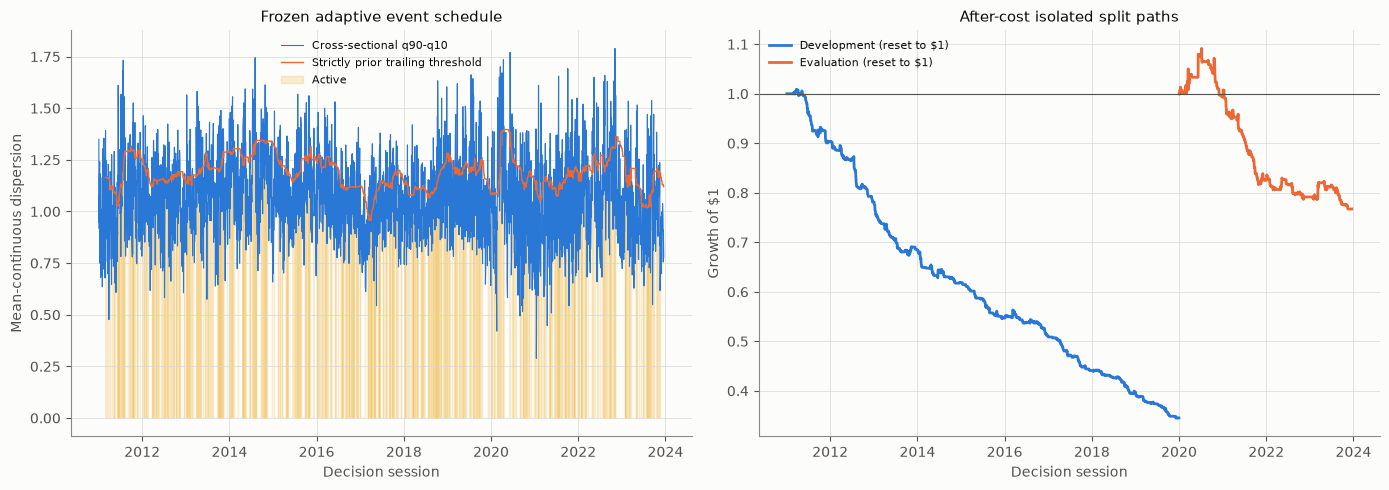

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
axes[0].plot(
    daily_input["session_date"],
    daily_input["dispersion"],
    color=CATEGORICAL[0],
    linewidth=0.8,
    label="Cross-sectional q90-q10",
)
axes[0].plot(
    daily_input["session_date"],
    daily_input["trailing_threshold"],
    color=CATEGORICAL[1],
    linewidth=1.0,
    label="Strictly prior trailing threshold",
)
axes[0].fill_between(
    daily_input["session_date"],
    0,
    daily_input["dispersion"],
    where=daily_input["active"],
    color=CATEGORICAL[3],
    alpha=0.18,
    label="Active",
)
axes[0].set_xlabel("Decision session")
axes[0].set_ylabel("Mean-continuous dispersion")
axes[0].set_title("Frozen adaptive event schedule")
axes[0].legend(loc="best", fontsize=8)
for split_name, colour in (
    ("development", CATEGORICAL[0]),
    ("evaluation", CATEGORICAL[1]),
):
    daily = daily_paths[(split_name, "adaptive_dispersion")]
    axes[1].plot(
        daily["session_date"],
        np.cumprod(1.0 + daily["net_return"]),
        color=colour,
        label=f"{split_name.title()} (reset to $1)",
    )
axes[1].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Decision session")
axes[1].set_ylabel("Growth of $1")
axes[1].set_title("After-cost isolated split paths")
axes[1].legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "schedule_and_paths.png", dpi=170, bbox_inches="tight")
plt.show()

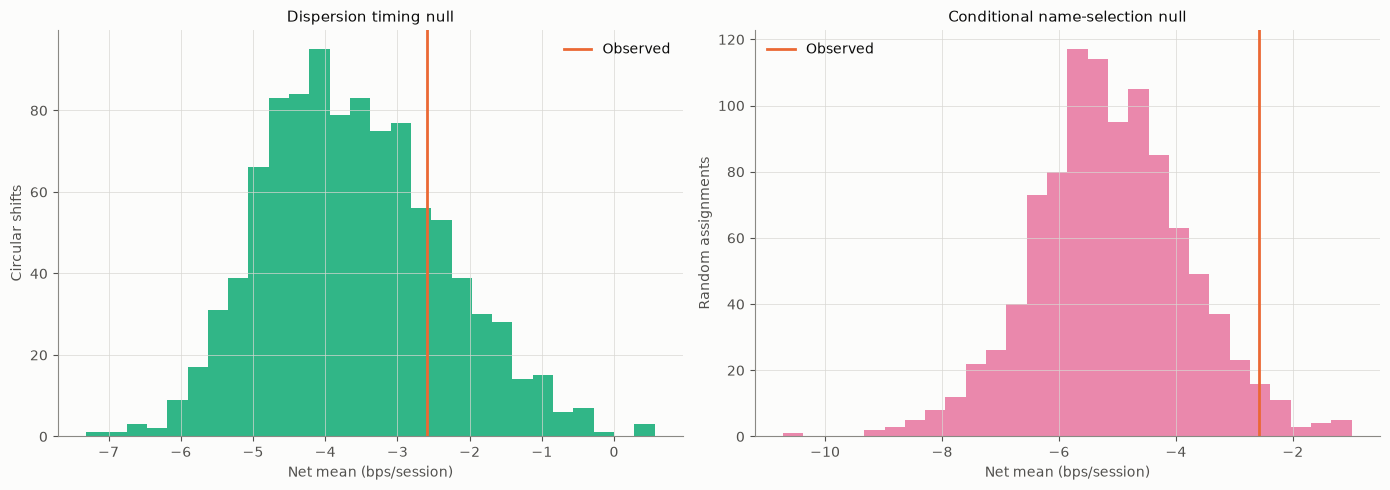

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
axes[0].hist(
    timing_null["mean_net"] * 10_000,
    bins=28,
    color=CATEGORICAL[2],
    alpha=0.9,
)
axes[0].axvline(
    observed_eval["mean_net"] * 10_000,
    color=CATEGORICAL[1],
    linewidth=2,
    label="Observed",
)
axes[0].set_xlabel("Net mean (bps/session)")
axes[0].set_ylabel("Circular shifts")
axes[0].set_title("Dispersion timing null")
axes[0].legend(loc="best")
axes[1].hist(
    name_null["mean_net"] * 10_000,
    bins=28,
    color=CATEGORICAL[4],
    alpha=0.9,
)
axes[1].axvline(
    observed_eval["mean_net"] * 10_000,
    color=CATEGORICAL[1],
    linewidth=2,
    label="Observed",
)
axes[1].set_xlabel("Net mean (bps/session)")
axes[1].set_ylabel("Random assignments")
axes[1].set_title("Conditional name-selection null")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mechanism_nulls.png", dpi=170, bbox_inches="tight")
plt.show()

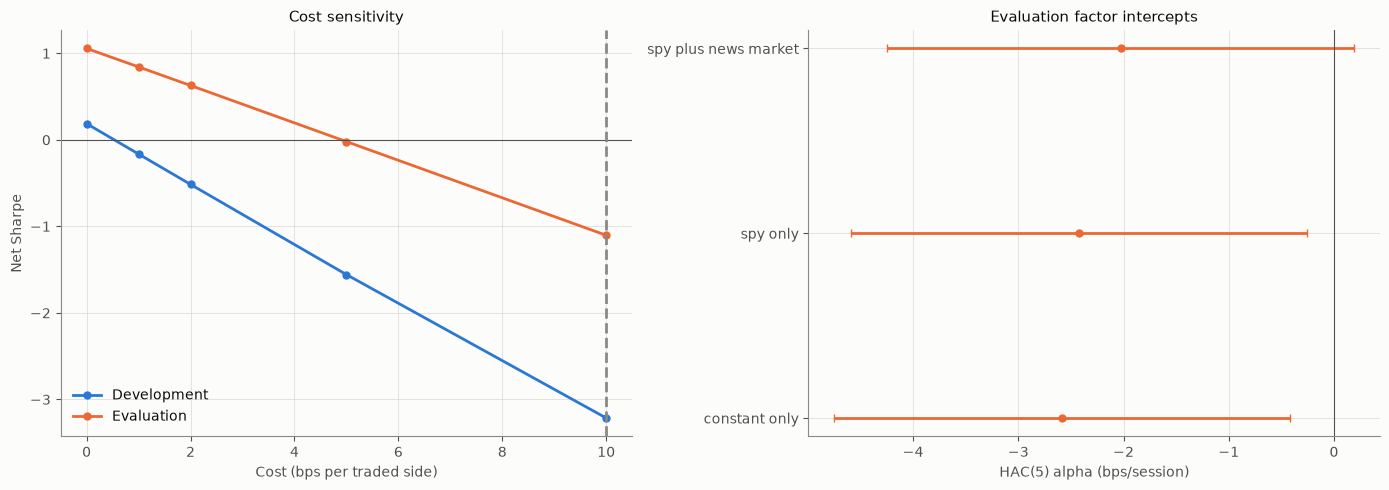

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
for split_name, colour in (
    ("development", CATEGORICAL[0]),
    ("evaluation", CATEGORICAL[1]),
):
    use = cost_curve.loc[cost_curve["split"].eq(split_name)]
    axes[0].plot(
        use["cost_bps_per_side"],
        use["sharpe_net"],
        marker="o",
        color=colour,
        label=split_name.title(),
    )
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(loc="best")
y = np.arange(len(factor_models))
axes[1].errorbar(
    factor_models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            factor_models["alpha_bps_session"]
            - factor_models["alpha_ci_low_bps_session"],
            factor_models["alpha_ci_high_bps_session"]
            - factor_models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=3,
)
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_yticks(y, factor_models["model"].str.replace("_", " "))
axes[1].set_xlabel("HAC(5) alpha (bps/session)")
axes[1].set_title("Evaluation factor intercepts")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "costs_and_factor_alpha.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence

In [12]:
feasibility.to_csv(OUTPUT_DIR / "feasibility.csv", index=False)
outcome_availability_audit.to_csv(
    OUTPUT_DIR / "outcome_availability_audit.csv", index=False
)
daily_input.to_csv(OUTPUT_DIR / "input_schedule.csv", index=False)
strategy_results.to_csv(OUTPUT_DIR / "strategy_results.csv", index=False)
accounting_audit.to_csv(OUTPUT_DIR / "accounting_audit.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
inference.to_csv(OUTPUT_DIR / "inference.csv", index=False)
evaluation_halves.to_csv(OUTPUT_DIR / "evaluation_halves.csv", index=False)
year_results.to_csv(OUTPUT_DIR / "evaluation_years.csv", index=False)
timing_null.to_csv(OUTPUT_DIR / "timing_null.csv", index=False)
name_null.to_csv(OUTPUT_DIR / "conditional_name_null.csv", index=False)
mechanism_inference.to_csv(OUTPUT_DIR / "mechanism_inference.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
symbol_gross.to_csv(OUTPUT_DIR / "symbol_gross_contributions.csv", index=False)
concentration.to_csv(OUTPUT_DIR / "concentration.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for (split_name, strategy_name), daily in daily_paths.items():
    daily.to_parquet(
        OUTPUT_DIR / f"{split_name}_{strategy_name}_daily.parquet", index=False
    )

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "POST_RESEARCH_CROSS_REGIME_FNSPID_TRANSFER",
    "notebook": "40_fnspid_lseg_gemma_continuous_rule_transfer.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "notebook39_manifest": str(NOTEBOOK39_MANIFEST.relative_to(REPO_ROOT)),
        "notebook39_manifest_sha256": sha256_file(NOTEBOOK39_MANIFEST),
        "fnspid_aggregators": str(AGGREGATE_PATH.relative_to(REPO_ROOT)),
        "fnspid_aggregators_sha256": sha256_file(AGGREGATE_PATH),
        "fnspid_panel": str(PANEL_PATH.relative_to(REPO_ROOT)),
        "fnspid_panel_sha256": sha256_file(PANEL_PATH),
        "licensed_headline_text_loaded": False,
        "lseg_return_loaded": False,
        "fnspid_return_opened_after_specification": True,
    },
    "translation": {
        "source_rule": selected_spec,
        "source_adaptive_schedule": adaptive_spec,
        "universe_translation": "all FNSPID news-bearing priced firms",
        "breadth_translation": "ceil(available names * 2/33), minimum two per leg",
        "signal": "mean_continuous FinBERT signed score",
        "direction": "positive long, negative short",
        "gross_exposure": 1.0,
        "single_name_cap": SINGLE_NAME_CAP,
        "holding_intervals": 1,
        "cost_bps_per_side": COST_BPS,
        "boundary_policy": "cash on the final development interval crossing into evaluation",
        "accounting": "validated drift-aware open-to-open ledger plus terminal liquidation",
    },
    "frozen_gates": {
        "minimum_active_sessions": MINIMUM_ACTIVE_SESSIONS,
        "cash_and_stability": (
            "evaluation net Sharpe > 0, break-even > 10 bps, cash CI low > 0, "
            "cash p < 0.05, development and both evaluation-half Sharpes >= 0"
        ),
        "mechanism": "both timing and conditional-name BH q < 0.05 with positive effects",
        "factor_alpha": "SPY-plus-news-market HAC(5) intercept CI low > 0 and p < 0.05",
    },
    "feasibility": json.loads(feasibility.to_json(orient="records", date_format="iso"))[0],
    "outcome_availability_audit": json.loads(
        outcome_availability_audit.to_json(orient="records")
    )[0],
    "strategy_results": json.loads(strategy_results.to_json(orient="records")),
    "inference": json.loads(inference.to_json(orient="records")),
    "evaluation_halves": json.loads(evaluation_halves.to_json(orient="records")),
    "mechanism_inference": json.loads(
        mechanism_inference.to_json(orient="records")
    ),
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "concentration": json.loads(concentration.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "FNSPID uses FinBERT rather than Gemma, so this is construction transfer rather than same-scorer validation",
        "only nine immutable LSEG symbols exist in the FNSPID checkpoint, requiring relative-breadth translation",
        "FNSPID date-only news uses the conservative strictly-next-session mapping",
        "the news-bearing cross-section changes through time with archive coverage",
        "one selected CLF session is forced fully to cash because its immediate next-session source price is absent",
        "development and evaluation outcomes were opened elsewhere before this rule was proposed",
        "prices are split adjusted but not dividend adjusted",
        "borrow fees, variable spreads, impact, and intraday microstructure are omitted",
        "circular shifts assume approximate stationarity and wrap endpoints",
        "the conditional name null uses 999 seeded assignments",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "POST_RESEARCH_CROSS_REGIME_FNSPID_TRANSFER",
  "notebook": "40_fnspid_lseg_gemma_continuous_rule_transfer.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260814,
  "input": {
    "notebook39_manifest": "final_experiments/outputs/39_gemma_continuous_portability/manifest.json",
    "notebook39_manifest_sha256": "f24bff1a8ef71c1f7296c0bee3eba5a3ec4c2adde1bf7b8135deb05b80cd73e1",
    "fnspid_aggregators": "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet",
    "fnspid_aggregators_sha256": "1ca1c38109bc06af232119adeff17de66a567174d457038bc923a930a2da61f1",
    "fnspid_panel": "final_experiments/outputs/01_panel/fnspid_firm_day_panel.parquet",
    "fnspid_panel_sha256": "928b2845307fba36d4b0464bb212ba2c4001b051a029cf18102f4ac2d2627c2c",
    "licensed_headline_text_loaded": false,
    "lseg_return_loaded": false,
    "fnspid_return_opened_after_specification": true
  },
  "translation": {
    "source_rule": {
   

## Decision

**NO-GO as a deployable 10 bps strategy, but a useful gross-signal result.**
The frozen adaptive construction earns evaluation gross Sharpe **1.056** and
**+27.29%** gross total return, yet 10 bps per traded side turns this into net
Sharpe **-1.103** and **-23.27%**. Its evaluation break-even is only **4.904
bps/side**, and net performance is significantly below cash at **-2.585
bps/session** with a block-bootstrap 95% interval of **[-4.662, -0.410]** and
p = **0.0185**. Both evaluation halves also have negative 10 bps net Sharpe.
The frozen deployment gate therefore fails.

The cost curve localises the failure. Evaluation remains positive at 0-2 bps
(2 bps: Sharpe **0.628**, total return **+15.05%**) and is approximately flat
at 5 bps. This is not stable cross-era evidence, however: development gross
Sharpe is only **0.187** and its break-even is **0.532 bps/side**. The result
supports a limited claim that a continuous, dispersion-gated sentiment rank
can transfer from LSEG/Gemma into a broad FNSPID/FinBERT cross-section at the
**gross** level during the evaluation era; it does not support an investable
strategy or a scorer-equivalence claim.

The mechanism evidence is suggestive but does not pass the frozen family.
Conditional name selection beats matched random names by **2.528 bps/session**
with nominal p = **0.035**, but q = **0.070** after the declared two-test BH
correction. Dispersion timing has p = **0.208**. The gross result is not a
single-name artefact: 566/570 symbols trade, mean active breadth is 26.45 names,
the largest weight is 10%, and absolute-contribution HHI is 0.0027.

Do not tune breadth, threshold, holding period, or cost assumptions on this
opened sample. The next defensible strategy work is an **input-only** audit of
signal persistence and turnover sources. A lower-turnover holding or
rebalancing rule may then be frozen from signal-path diagnostics and tested on
genuinely new dates; it must not be selected from these realised returns.